# The Price Is Right

### And now, to evaluate our fine-tuned open source model



In [1]:
!pip install -q --upgrade bitsandbytes trl
!wget -q https://raw.githubusercontent.com/ed-donner/llm_engineering/main/week7/util.py -O util.py

In [2]:
# imports

import os
import re
import math
from tqdm import tqdm
# from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
from peft import PeftModel
from util import evaluate

In [3]:
# Constants

BASE_MODEL = "meta-llama/Llama-3.2-3B"
PROJECT_NAME = "price"
HF_USER = "ed-donner" # your HF name here!

LITE_MODE = False

DATA_USER = "ed-donner"
DATASET_NAME = f"{DATA_USER}/items_prompts_lite" if LITE_MODE else f"{DATA_USER}/items_prompts_full"

if LITE_MODE:
  RUN_NAME = "2025-11-30_15.10.55-lite"
  REVISION = None
else:
  RUN_NAME = "2025-11-28_18.47.07"
  REVISION = "b19c8bfea3b6ff62237fbb0a8da9779fc12cefbd"

PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
HUB_MODEL_NAME = f"{HF_USER}/{PROJECT_RUN_NAME}"


# Hyper-parameters - QLoRA

QUANT_4_BIT = True
capability = torch.cuda.get_device_capability()
use_bf16 = capability[0] >= 8

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.


In [4]:
# Log in to HuggingFace

# hf_token = userdata.get('HF_TOKEN')
# login(hf_token, add_to_git_credential=True)

import os
from dotenv import load_dotenv
from huggingface_hub import login

# .env laden
load_dotenv()

# Token aus .env lesen
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN wurde nicht in der .env Datei gefunden")

# HuggingFace Login
login(token=hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [5]:
dataset = load_dataset(DATASET_NAME)
test = dataset['test']

In [6]:
test[0]

{'prompt': 'What does this cost to the nearest dollar?\n\nTitle: Excess V2 Distortion/Modulation Pedal  \nCategory: Music Pedals  \nBrand: Old Blood Noise  \nDescription: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  \nDetails: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.\n\nPrice is $',
 'completion': '219.0'}

## Now load the Tokenizer and Model

In [7]:
# pick the right quantization

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16 if use_bf16 else torch.float16,
  )

In [8]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

# Load the fine-tuned model with PEFT
if REVISION:
  fine_tuned_model = PeftModel.from_pretrained(base_model, HUB_MODEL_NAME, revision=REVISION)
else:
  fine_tuned_model = PeftModel.from_pretrained(base_model, HUB_MODEL_NAME)


print(f"Memory footprint: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/data/Projects/llm_engineering/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Memory footprint: 3753.7 MB


In [9]:
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 3072)
        (layers): ModuleList(
          (0-27): 28 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=256, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=256, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lo

# THE MOMENT OF TRUTH!

## Use the model in inference mode

Trying to beat "human" level of performance at $87.62

Or possibly close to gpt-4.1-nano at $62.51

## Caveat

Keep in mind that prices of goods vary considerably; the model can't predict things like sale prices that it doesn't have any information about.

In [10]:
def model_predict(item):
    inputs = tokenizer(item["prompt"],return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_ids = fine_tuned_model.generate(**inputs, max_new_tokens=8)
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_len:]
    return tokenizer.decode(generated_ids)

In [11]:
set_seed(42)
evaluate(model_predict, test)


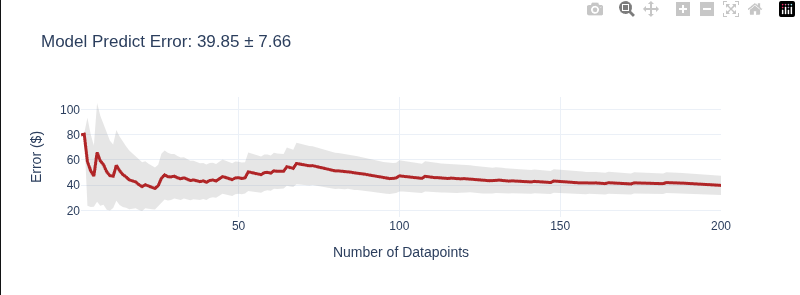

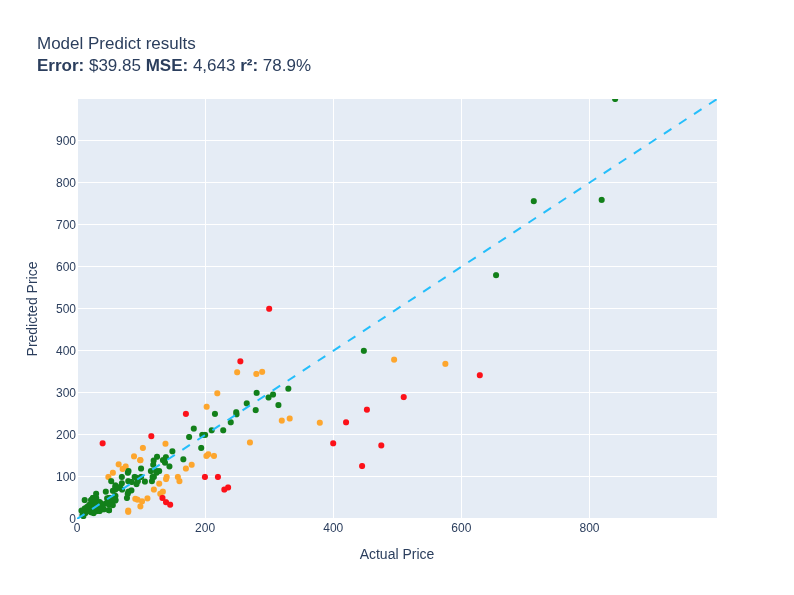